# Full Pipeline Demo: From Survey Design to Analysis

This notebook demonstrates the complete **siamang** workflow:
1. Define variables with metadata (labels, scales, valid ranges)
2. Build a multi-page questionnaire with conditional routing
3. Deploy locally and simulate data collection
4. Analyze results using the **declarative reporting API** (`data.report.*`, `data.plot.*`)

The research scenario: a study of remote work, autonomy, digital surveillance,
and job satisfaction among IT professionals.

In [1]:
import siamang
from siamang import (
    AND,
    LikertScale,
    Matrix,
    NumericInput,
    OpenText,
    Page,
    Questionnaire,
    SingleChoice,
    Variable,
    VariableMap,
)

print(f"siamang version: {siamang.__version__}")

siamang version: 0.5.0


## 1. Variable Definitions

Each variable carries metadata that the reporting engine uses automatically:
- **label**: human-readable name for table headers and axis labels
- **labels**: value-label mapping for categorical codes
- **scale**: measurement level (nominal/ordinal/interval/ratio) — determines which statistical tests to apply
- **valid_range**: acceptable numeric bounds for validation

In [2]:
# --- Consent ---
consent = Variable("consent", scale="nominal", label="Informed Consent", labels={1: "Yes", 0: "No"})

# --- Demographics ---
age = Variable("age", scale="ratio", label="Age (years)", dtype="int", valid_range=(18, 75))

gender = Variable(
    "gender", scale="nominal", label="Gender", labels={1: "Male", 2: "Female", 3: "Non-binary"}
)

it_role = Variable(
    "it_role",
    scale="nominal",
    label="IT Role",
    labels={
        1: "Software Engineer",
        2: "Data Scientist",
        3: "DevOps / SRE",
        4: "Product Manager",
        5: "QA / Tester",
    },
)

experience = Variable(
    "experience", scale="ratio", label="Years of Experience", dtype="int", valid_range=(0, 50)
)

# --- Remote Work ---
remote_freq = Variable(
    "remote_freq",
    scale="ordinal",
    label="Remote Work Frequency",
    labels={
        1: "Never (on-site)",
        2: "1-2 days/week",
        3: "Hybrid (3 days)",
        4: "Mostly remote (4 days)",
        5: "Fully remote",
    },
)

# --- Surveillance (Matrix) ---
surv_keystroke = Variable(
    "surv_keystroke",
    scale="ordinal",
    label="Keystroke logging acceptance",
    labels={1: "Strongly disagree", 2: "Disagree", 3: "Neutral", 4: "Agree", 5: "Strongly agree"},
)

surv_camera = Variable(
    "surv_camera",
    scale="ordinal",
    label="Webcam monitoring acceptance",
    labels={1: "Strongly disagree", 2: "Disagree", 3: "Neutral", 4: "Agree", 5: "Strongly agree"},
)

surv_git = Variable(
    "surv_git",
    scale="ordinal",
    label="Git commit metrics acceptance",
    labels={1: "Strongly disagree", 2: "Disagree", 3: "Neutral", 4: "Agree", 5: "Strongly agree"},
)

# --- Outcomes ---
satisfaction = Variable(
    "satisfaction",
    scale="interval",
    label="Job Satisfaction",
    labels={1: "Very low", 2: "Low", 3: "Neutral", 4: "High", 5: "Very high"},
)

autonomy = Variable(
    "autonomy",
    scale="ordinal",
    label="Perceived Autonomy",
    labels={1: "Very low", 2: "Low", 3: "Moderate", 4: "High", 5: "Very high"},
)

story = Variable("story", scale="nominal", label="Open-ended comment")

# --- Variable Map ---
variables = VariableMap()
variables.add_many(
    [
        consent,
        age,
        gender,
        it_role,
        experience,
        remote_freq,
        surv_keystroke,
        surv_camera,
        surv_git,
        satisfaction,
        autonomy,
        story,
    ]
)

print(f"Defined {len(variables)} variables")
for v in variables.values():
    print(f"  {v.name:20s} | {v.scale:8s} | {v.label}")

Defined 12 variables
  consent              | nominal  | Informed Consent
  age                  | ratio    | Age (years)
  gender               | nominal  | Gender
  it_role              | nominal  | IT Role
  experience           | ratio    | Years of Experience
  remote_freq          | ordinal  | Remote Work Frequency
  surv_keystroke       | ordinal  | Keystroke logging acceptance
  surv_camera          | ordinal  | Webcam monitoring acceptance
  surv_git             | ordinal  | Git commit metrics acceptance
  satisfaction         | interval | Job Satisfaction
  autonomy             | ordinal  | Perceived Autonomy
  story                | nominal  | Open-ended comment


## 2. Questionnaire Assembly

Pages with conditional routing (`show_if`) — respondents who refuse consent
skip all subsequent pages. The surveillance matrix only appears for remote workers.

In [3]:
q_consent = SingleChoice(
    "Do you consent to participate in this study?", var=consent, required=True, display="buttons"
)

q_age = NumericInput("What is your age?", var=age)
q_gender = SingleChoice("What is your gender?", var=gender, display="radio")
q_role = SingleChoice("What is your primary IT role?", var=it_role, display="dropdown")
q_experience = NumericInput("Years of professional experience?", var=experience)
q_remote = SingleChoice("How often do you work remotely?", var=remote_freq, display="radio")

q_surveillance = Matrix(
    "To what extent do you accept the following monitoring practices?",
    var=[surv_keystroke, surv_camera, surv_git],
    subquestions=["Keystroke logging", "Webcam monitoring", "Git commit metrics"],
    column_labels=["Strongly disagree", "Disagree", "Neutral", "Agree", "Strongly agree"],
)

q_satisfaction = LikertScale(
    "How satisfied are you with your current job?",
    var=satisfaction,
    points=5,
    left_label="Very dissatisfied",
    right_label="Very satisfied",
)
q_autonomy = LikertScale(
    "How much autonomy do you have in your daily work?",
    var=autonomy,
    points=5,
    left_label="Very low",
    right_label="Very high",
)
q_story = OpenText(
    "Any additional comments about your work experience?", var=story, multiline=True, max_chars=500
)

# --- Pages with routing ---
page_consent = Page(name="consent", title="Informed Consent", items=[q_consent])
page_demo = Page(
    name="demographics",
    title="Demographics",
    items=[q_age, q_gender, q_role, q_experience],
    show_if=consent.eq(1),
)
page_remote = Page(name="remote", title="Remote Work", items=[q_remote], show_if=consent.eq(1))
page_surveillance = Page(
    name="surveillance",
    title="Workplace Monitoring",
    items=[q_surveillance],
    show_if=AND(consent.eq(1), remote_freq.ge(2)),
)
page_outcomes = Page(
    name="outcomes",
    title="Work Outcomes",
    items=[q_satisfaction, q_autonomy, q_story],
    show_if=consent.eq(1),
)

survey = Questionnaire(
    title="Remote Work, Autonomy & Digital Surveillance",
    pages=[page_consent, page_demo, page_remote, page_surveillance, page_outcomes],
    variables=variables,
)

print(f"Questionnaire: {survey.title}")
print(f"Pages: {len(survey.pages)}")
for p in survey.pages:
    cond = f" [show_if: {p.show_if}]" if p.show_if else ""
    print(f"  - {p.title} ({len(p.items)} items){cond}")

Questionnaire: Remote Work, Autonomy & Digital Surveillance
Pages: 5
  - Informed Consent (1 items)
  - Demographics (4 items) [show_if: {consent} = 1]
  - Remote Work (1 items) [show_if: {consent} = 1]
  - Workplace Monitoring (1 items) [show_if: ({consent} = 1) and ({remote_freq} >= 2)]
  - Work Outcomes (3 items) [show_if: {consent} = 1]


## 3. Data Simulation

The simulator respects page-level `show_if` conditions:
respondents who refuse consent get NaN for all subsequent variables.

In [4]:
data = survey.simulate(n=300, seed=42)

print(f"DataFrame shape: {data.frame.shape}")
print(f"Variables in metadata: {len(data.variables)}")
print()
print("First 10 rows:")
data.frame.head(10)

DataFrame shape: (300, 12)
Variables in metadata: 12

First 10 rows:


,consent,age,gender,it_role,experience,remote_freq,surv_keystroke,surv_camera,surv_git,satisfaction,autonomy,story
0,1,19.0,3.0,3.0,15.0,2.0,2.0,1.0,5.0,1.0,5.0,sample text
1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,19.0,1.0,2.0,14.0,5.0,5.0,1.0,5.0,2.0,5.0,sample text
3,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,46.0,3.0,3.0,0.0,2.0,4.0,3.0,3.0,2.0,2.0,sample text
5,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1,23.0,2.0,1.0,22.0,3.0,5.0,3.0,1.0,4.0,5.0,sample text
7,1,42.0,1.0,5.0,18.0,5.0,3.0,5.0,2.0,1.0,1.0,sample text
8,1,67.0,2.0,1.0,14.0,1.0,NaN,NaN,NaN,4.0,3.0,sample text
9,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Data Overview

Using `describe_variables()` to see N, missing counts, and scales.

In [5]:
desc = data.describe_variables()
print(f"Variable summary ({len(desc)} variables):")
desc

Variable summary (12 variables):


,name,label,scale,n,n_missing,n_unique
0,consent,Informed Consent,nominal,300,0,2
1,age,Age (years),ratio,300,148,56
2,gender,Gender,nominal,300,148,3
3,it_role,IT Role,nominal,300,148,5
4,experience,Years of Experience,ratio,300,148,49
5,remote_freq,Remote Work Frequency,ordinal,300,148,5
6,surv_keystroke,Keystroke logging acceptance,ordinal,300,175,5
7,surv_camera,Webcam monitoring acceptance,ordinal,300,175,5
8,surv_git,Git commit metrics acceptance,ordinal,300,175,5
9,satisfaction,Job Satisfaction,interval,300,148,5


## 5. Declarative Reporting: Frequency Tables

The `data.report.freq()` method automatically:
- Resolves value labels from variable metadata
- Computes N, %, and cumulative %
- Adds a Total row

No manual label mapping needed — just pass the variable name.

In [6]:
# IT Role distribution
table_role = data.report.freq("it_role")
print(table_role.to_markdown())

| Value | Label | N | % | Cumulative % |
|---|---|---|---|---|
| 1.0 | Software Engineer | 29 | 19.1 | 19.1 |
| 2.0 | Data Scientist | 33 | 21.7 | 40.8 |
| 3.0 | DevOps / SRE | 36 | 23.7 | 64.5 |
| 4.0 | Product Manager | 29 | 19.1 | 83.6 |
| 5.0 | QA / Tester | 25 | 16.4 | 100.0 |
|  | Total | 152 | 100.0 | 100.0 |

Variable = IT Role; N valid = 152


In [7]:
# Remote Work Frequency — sorted by count (descending)
table_remote = data.report.freq("remote_freq", sort="freq")
print(table_remote.to_markdown())

| Value | Label | N | % | Cumulative % |
|---|---|---|---|---|
| 5.0 | Fully remote | 34 | 22.4 | 22.4 |
| 3.0 | Hybrid (3 days) | 31 | 20.4 | 42.8 |
| 2.0 | 1-2 days/week | 31 | 20.4 | 63.2 |
| 4.0 | Mostly remote (4 days) | 29 | 19.1 | 82.3 |
| 1.0 | Never (on-site) | 27 | 17.8 | 100.1 |
|  | Total | 152 | 100.0 | 100.0 |

Variable = Remote Work Frequency; N valid = 152


## 6. Cross-Tabulation with Chi-Square Test

`data.report.crosstab()` automatically:
- Resolves labels for both row and column variables
- Computes Chi-square, degrees of freedom, p-value, and Cramer's V
- Supports percentage modes: "none" (counts), "row", "col", "total"

In [8]:
# IT Role × Remote Frequency (counts)
xtab = data.report.crosstab("it_role", "remote_freq")
print(xtab.to_markdown())

| IT Role | Never (on-site) | 1-2 days/week | Hybrid (3 days) | Mostly remote (4 days) | Fully remote | Total |
|---|---|---|---|---|---|---|
| Software Engineer | 5 | 5 | 5 | 5 | 9 | 29 |
| Data Scientist | 8 | 6 | 5 | 7 | 7 | 33 |
| DevOps / SRE | 4 | 9 | 8 | 9 | 6 | 36 |
| Product Manager | 8 | 8 | 5 | 4 | 4 | 29 |
| QA / Tester | 2 | 3 | 8 | 4 | 8 | 25 |
| Total | 27 | 31 | 31 | 29 | 34 | 152 |

χ² = 14.0770; df = 16; p = 0.5930; Cramér's V = 0.1520; N = 152


In [9]:
# Same cross-tab with row percentages
xtab_pct = data.report.crosstab("it_role", "remote_freq", pct="row")
print(xtab_pct.to_markdown())

| IT Role | Never (on-site) | 1-2 days/week | Hybrid (3 days) | Mostly remote (4 days) | Fully remote | Total |
|---|---|---|---|---|---|---|
| Software Engineer | 17.2 | 17.2 | 17.2 | 17.2 | 31.0 | 29 |
| Data Scientist | 24.2 | 18.2 | 15.2 | 21.2 | 21.2 | 33 |
| DevOps / SRE | 11.1 | 25.0 | 22.2 | 25.0 | 16.7 | 36 |
| Product Manager | 27.6 | 27.6 | 17.2 | 13.8 | 13.8 | 29 |
| QA / Tester | 8.0 | 12.0 | 32.0 | 16.0 | 32.0 | 25 |
| Total | 27.0 | 31.0 | 31.0 | 29.0 | 34.0 | 152 |

χ² = 14.0770; df = 16; p = 0.5930; Cramér's V = 0.1520; N = 152


## 7. Grouped Means with Automatic Test Selection

`data.report.means()` automatically selects the appropriate test:
- **Ordinal scale + 3+ groups** → Kruskal-Wallis H
- **Ordinal scale + 2 groups** → Mann-Whitney U
- **Interval/ratio scale + 3+ groups** → One-way ANOVA (F)
- **Interval/ratio scale + 2 groups** → Independent t-test

In [10]:
# Autonomy by Remote Frequency (ordinal → Kruskal-Wallis)
means_aut = data.report.means("autonomy", by="remote_freq")
print(means_aut.to_markdown())

| Remote Work Frequency | Mean | SD | Median | N |
|---|---|---|---|---|
| Never (on-site) | 3.148 | 1.322 | 3.0 | 27 |
| 1-2 days/week | 3.323 | 1.447 | 3.0 | 31 |
| Hybrid (3 days) | 2.968 | 1.449 | 2.0 | 31 |
| Mostly remote (4 days) | 2.759 | 1.38 | 3.0 | 29 |
| Fully remote | 2.824 | 1.487 | 3.0 | 34 |

Kruskal-Wallis H = 3.3930; p = 0.4943; N = 152; Variable = Perceived Autonomy


In [11]:
# Satisfaction by Remote Frequency (interval → ANOVA)
means_sat = data.report.means("satisfaction", by="remote_freq")
print(means_sat.to_markdown())

| Remote Work Frequency | Mean | SD | Median | N |
|---|---|---|---|---|
| Never (on-site) | 3.037 | 1.454 | 3.0 | 27 |
| 1-2 days/week | 3.065 | 1.209 | 3.0 | 31 |
| Hybrid (3 days) | 2.903 | 1.423 | 3.0 | 31 |
| Mostly remote (4 days) | 2.966 | 1.349 | 3.0 | 29 |
| Fully remote | 2.706 | 1.404 | 2.5 | 34 |

F = 0.3520; p = 0.8426; N = 152; Variable = Job Satisfaction


## 8. Declarative Charts: Bar Charts

`data.plot.bar()` automatically:
- Uses value labels for x-axis tick marks
- Uses variable label for axis title
- Annotates bars with counts

<Axes: title={'center': 'IT Role'}, xlabel='IT Role', ylabel='Count'>

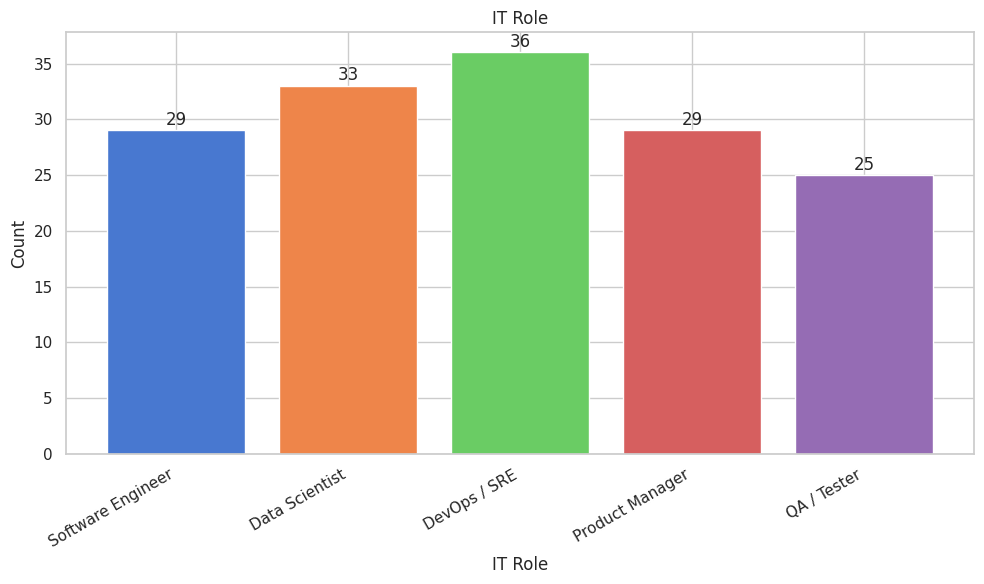

In [12]:
chart = data.plot.bar("it_role")
chart.plot()

<Axes: title={'center': 'Mean Perceived Autonomy by Remote Work Frequency'}, xlabel='Remote Work Frequency', ylabel='Mean Perceived Autonomy'>

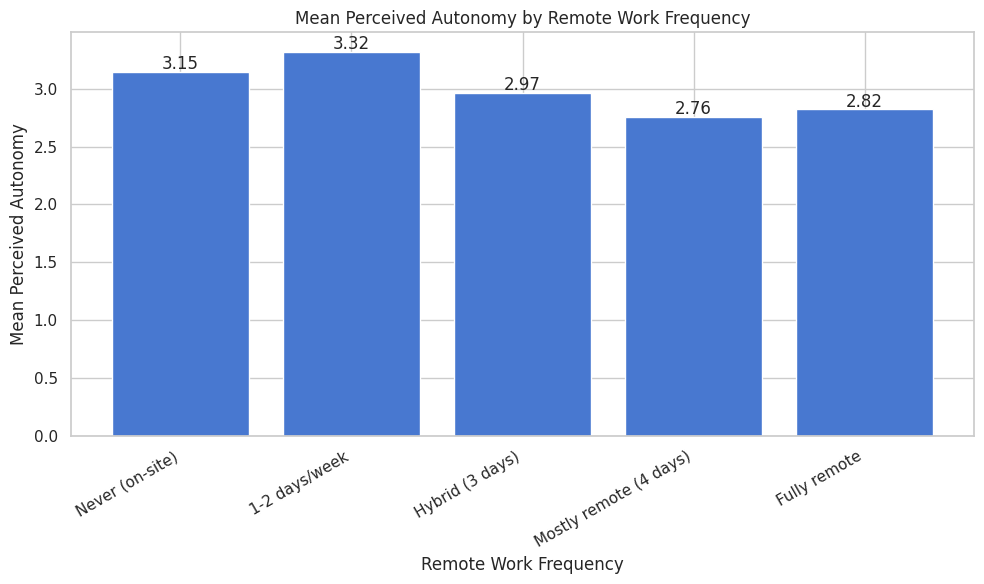

In [13]:
# Grouped mean bar chart: mean autonomy by remote frequency
chart = data.plot.bar("autonomy", by="remote_freq")
chart.plot()

## 9. Box Plots: Distribution Comparison

`data.plot.boxplot()` automatically resolves group labels from metadata.

<Axes: title={'center': 'Job Satisfaction by Remote Work Frequency'}, xlabel='Remote Work Frequency', ylabel='Job Satisfaction'>

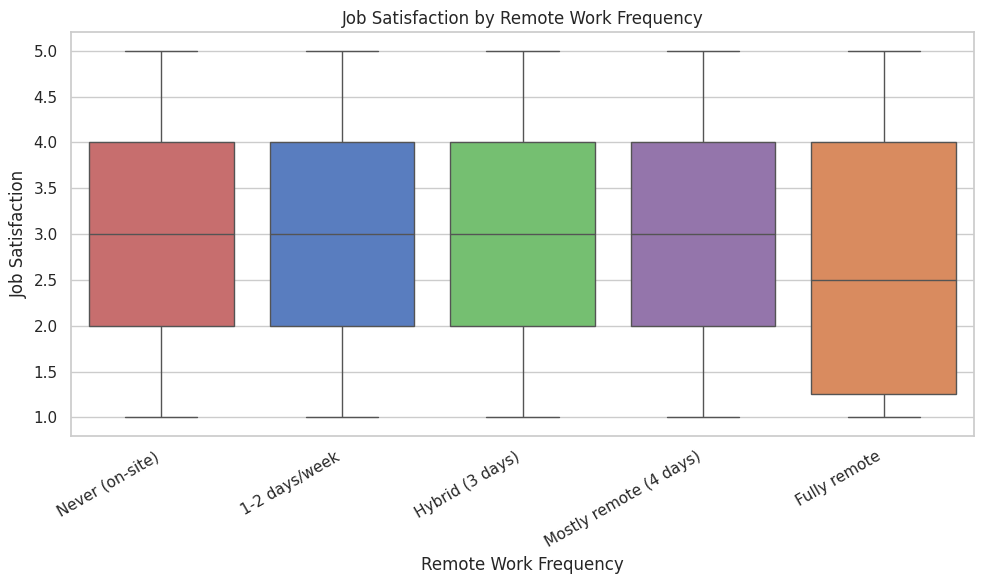

In [14]:
chart = data.plot.boxplot(
    "satisfaction", by="remote_freq", title="Job Satisfaction by Remote Work Frequency"
)
chart.plot()

<Axes: title={'center': 'Perceived Autonomy by Gender'}, xlabel='Gender', ylabel='Perceived Autonomy'>

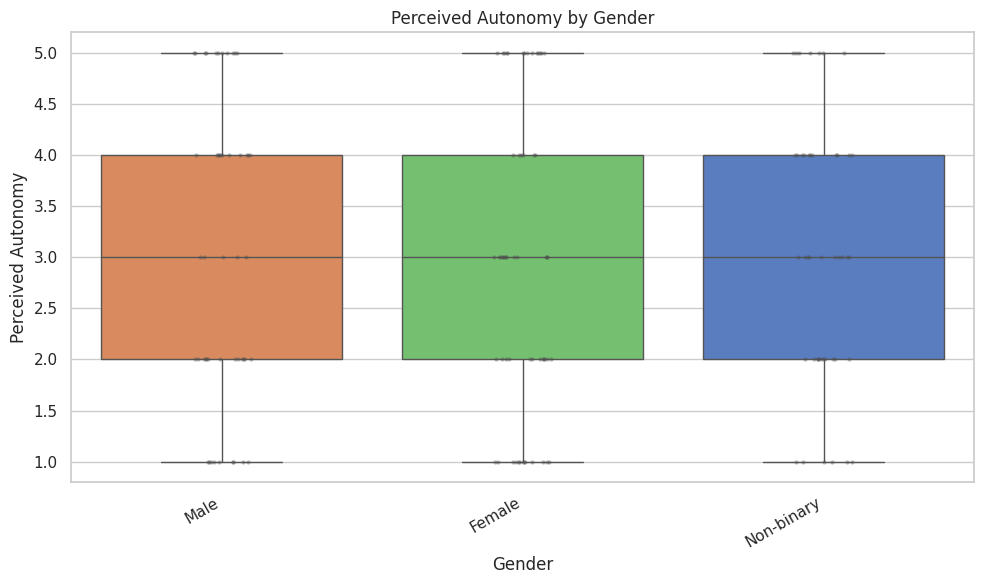

In [15]:
# Autonomy by gender with individual data points
chart = data.plot.boxplot(
    "autonomy", by="gender", show_points=True, title="Perceived Autonomy by Gender"
)
chart.plot()

## 10. Heatmaps

Two modes:
- With `by`: shows mean values of each variable grouped by a category
- Without `by`: shows Spearman correlation matrix

<Axes: title={'center': 'Surveillance Acceptance by Remote Work Frequency'}, xlabel='Remote Work Frequency'>

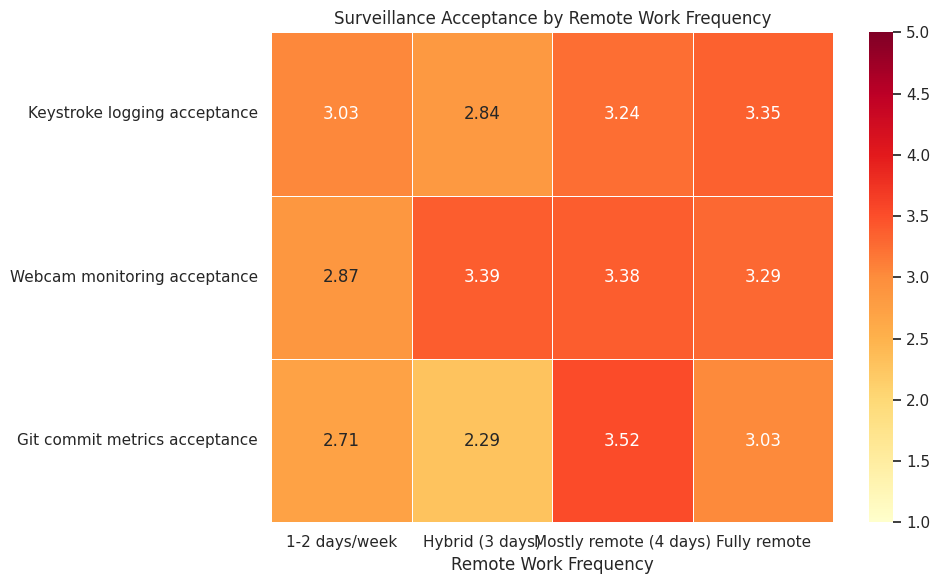

In [16]:
# Surveillance acceptance by remote frequency
chart = data.plot.heatmap(
    ["surv_keystroke", "surv_camera", "surv_git"],
    by="remote_freq",
    vmin=1,
    vmax=5,
    title="Surveillance Acceptance by Remote Work Frequency",
)
chart.plot()

<Axes: title={'center': 'Spearman Correlation Matrix'}>

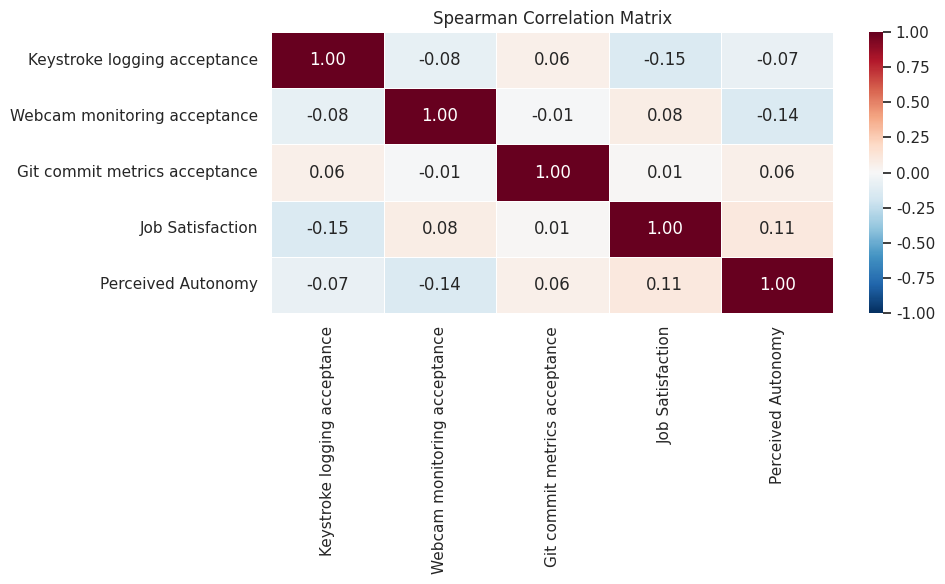

In [17]:
# Correlation matrix (Spearman) for all ordinal/interval outcomes
chart = data.plot.heatmap(
    ["surv_keystroke", "surv_camera", "surv_git", "satisfaction", "autonomy"],
    title="Spearman Correlation Matrix",
)
chart.plot()

## 11. Scatter Plots

`data.plot.scatter()` supports:
- Automatic trendline (linear regression)
- Hue grouping with value labels

<Axes: title={'center': 'Autonomy vs Satisfaction by Remote Frequency'}, xlabel='Job Satisfaction', ylabel='Perceived Autonomy'>

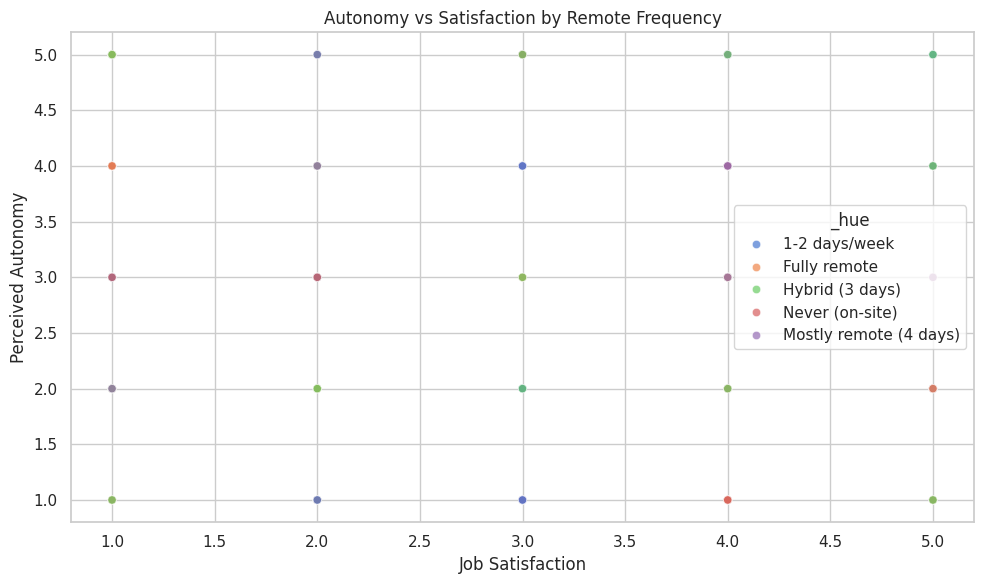

In [18]:
chart = data.plot.scatter(
    "satisfaction",
    "autonomy",
    hue="remote_freq",
    title="Autonomy vs Satisfaction by Remote Frequency",
)
chart.plot()

## 12. Export Capabilities

All tables support multiple output formats:
- `.to_frame()` → pandas DataFrame
- `.to_markdown()` → GitHub-flavored Markdown
- `.to_html()` → HTML table
- `.export_xlsx(path)` → Excel file

In [19]:
# Export cross-tabulation to multiple formats
xtab = data.report.crosstab("it_role", "remote_freq")

print("=== DataFrame ===")
display(xtab.to_frame())

print("\n=== Markdown ===")
print(xtab.to_markdown())

print("\n=== HTML (first 200 chars) ===")
print(xtab.to_html()[:200] + "...")

=== DataFrame ===


,IT Role,Never (on-site),1-2 days/week,Hybrid (3 days),Mostly remote (4 days),Fully remote,Total
0,Software Engineer,5,5,5,5,9,29
1,Data Scientist,8,6,5,7,7,33
2,DevOps / SRE,4,9,8,9,6,36
3,Product Manager,8,8,5,4,4,29
4,QA / Tester,2,3,8,4,8,25
5,Total,27,31,31,29,34,152



=== Markdown ===
| IT Role | Never (on-site) | 1-2 days/week | Hybrid (3 days) | Mostly remote (4 days) | Fully remote | Total |
|---|---|---|---|---|---|---|
| Software Engineer | 5 | 5 | 5 | 5 | 9 | 29 |
| Data Scientist | 8 | 6 | 5 | 7 | 7 | 33 |
| DevOps / SRE | 4 | 9 | 8 | 9 | 6 | 36 |
| Product Manager | 8 | 8 | 5 | 4 | 4 | 29 |
| QA / Tester | 2 | 3 | 8 | 4 | 8 | 25 |
| Total | 27 | 31 | 31 | 29 | 34 | 152 |

χ² = 14.0770; df = 16; p = 0.5930; Cramér's V = 0.1520; N = 152

=== HTML (first 200 chars) ===
<table class="dataframe siamang-table">
  <thead>
    <tr style="text-align: right;">
      <th>IT Role</th>
      <th>Never (on-site)</th>
      <th>1-2 days/week</th>
      <th>Hybrid (3 days)</th>
...


## 13. Summary

The **declarative reporting API** eliminates boilerplate:

| Traditional approach | siamang declarative |
|:-----|:-----|
| `pd.crosstab(...)` + manual labels + `scipy.stats.chi2_contingency(...)` | `data.report.crosstab("it_role", "remote_freq")` |
| `df.groupby(...).agg(...)` + rename + `kruskal(...)` | `data.report.means("autonomy", by="remote_freq")` |
| `sns.boxplot(...)` + manual xtick labels + title | `data.plot.boxplot("autonomy", by="remote_freq")` |

All metadata (labels, scales, value labels) is resolved automatically from the variable definitions.

In [20]:
print("Pipeline complete!")
print(f"  - {len(data.variables)} variables with full metadata")
print(f"  - {data.frame.shape[0]} respondents simulated")
print("  - Conditional routing: consent → demographics → remote → surveillance → outcomes")
print("  - Tables: FreqTable, CrossTable, GroupMeanTable")
print("  - Charts: BarChart, BoxPlot, HeatMap, ScatterPlot")
print("  - Output: .to_frame(), .to_markdown(), .to_html(), .export_xlsx()")

Pipeline complete!
  - 12 variables with full metadata
  - 300 respondents simulated
  - Conditional routing: consent → demographics → remote → surveillance → outcomes
  - Tables: FreqTable, CrossTable, GroupMeanTable
  - Charts: BarChart, BoxPlot, HeatMap, ScatterPlot
  - Output: .to_frame(), .to_markdown(), .to_html(), .export_xlsx()
